# Hồi quy tuyến tính huấn luyện bằng Gradient Descent (SGD): dự đoán lương theo kinh nghiệm

Bài toán: cho số năm kinh nghiệm `Experience` (đặc trưng một chiều, $d = 1$), dự đoán mức lương `Salary`. Mô hình hồi quy tuyến tính $\hat{y} = w x + b$ được huấn luyện bằng **gradient descent ngẫu nhiên theo từng mẫu** (per-sample SGD) với **tốc độ học cố định**. Notebook tái hiện đúng đoạn mã đề bài (100 epoch), sau đó **tăng số epoch vượt 500 để so sánh sự hội tụ**, và đối chiếu điểm hội tụ với nghiệm đóng (closed-form OLS) nhằm làm rõ một hiện tượng quan trọng về phương pháp luận.

Kết luận chính rút ra từ thực nghiệm: với tốc độ học **cố định**, vòng lặp SGD per-sample **vẫn hội tụ** (loss phẳng ra sau khoảng 500–2000 epoch), nhưng hội tụ về một **điểm cố định bị chệch** so với nghiệm tối ưu OLS. Tăng số epoch chỉ giúp đạt tới điểm cố định đó nhanh và chắc hơn, **không** xoá được độ chệch; muốn giảm chệch phải giảm tốc độ học (hoặc dùng gradient toàn batch).

## 1. Cơ sở toán học

**Mô hình.** Với một mẫu $(x, y)$, dự đoán $\hat{y} = \langle w, x\rangle + b$. Hàm mất mát đánh giá trên toàn tập là sai số bình phương trung bình
$$\mathcal{L}(w, b) = \frac{1}{N}\sum_{i=1}^{N}\big(\hat{y}_i - y_i\big)^2 .$$

**Gradient theo từng mẫu.** Đề bài dùng mất mát bình phương của *một* mẫu, $\ell_i = (\hat{y}_i - y_i)^2$, với đạo hàm
$$\frac{\partial \ell_i}{\partial w} = 2(\hat{y}_i - y_i)\,x_i, \qquad \frac{\partial \ell_i}{\partial b} = 2(\hat{y}_i - y_i).$$

**Cập nhật SGD (per-sample).** Mỗi epoch duyệt lần lượt từng mẫu theo đúng thứ tự và cập nhật ngay:
$$w \leftarrow w - \eta\,2(\hat{y}_i - y_i)\,x_i, \qquad b \leftarrow b - \eta\,2(\hat{y}_i - y_i),$$
với $\eta$ là tốc độ học (`LEARNING_RATE`).

**Nghiệm đóng (OLS) để đối chiếu.** Vì $d = 1$, nghiệm tối thiểu hoá $\mathcal{L}$ có dạng tường minh
$$w^\star = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sum_i (x_i - \bar{x})^2}, \qquad b^\star = \bar{y} - w^\star \bar{x}.$$
Đây là "đích đến" lý thuyết: mọi thuật toán giảm gradient *không chệch* phải tiến về $(w^\star, b^\star)$.

## 2. Thiết lập dữ liệu và khởi tạo tham số

Dữ liệu gồm 4 mẫu, đặc trưng một chiều `Experience` $\in \{3,4,5,6\}$ và nhãn `Salary`. Tham số được khởi tạo $w = 0,\ b = 0$ đúng như đề bài.

In [1]:
import numpy as np

# Du lieu: so nam kinh nghiem (Experience) -> luong (Salary)
X_train = np.array([[3], [4], [5], [6]], dtype=float)  # (N, d) voi d = 1
y_train = np.array([60, 55, 66, 93], dtype=float)

def initialize_params():
    d = X_train.shape[1]          # so chieu cua dac trung
    w = np.zeros(d)               # khoi tao w = 0  (shape (d,))
    b = 0.0                       # khoi tao b = 0
    return w, b

N = len(y_train)
LEARNING_RATE = 1e-2
print("X_train shape:", X_train.shape, "| N =", N, "| d =", X_train.shape[1])

X_train shape: (4, 1) | N = 4 | d = 1


## 3. Phiên bản gốc (đề bài): chạy đúng 100 epoch

Tái hiện nguyên văn vòng lặp huấn luyện của đề bài: SGD per-sample, tốc độ học cố định $\eta = 10^{-2}$, 100 epoch. In tiến trình loss mỗi 10 epoch và dự đoán lương khi `Experience = 7`.

In [2]:
w, b = initialize_params()
epoch_max = 100

for epoch in range(epoch_max):
    for i in range(N):
        x = X_train[i]                 # vector shape (d,)
        y = y_train[i]
        y_pred = np.dot(w, x) + b       # output
        dw = 2 * (y_pred - y) * x       # gradient theo w
        db = 2 * (y_pred - y)           # gradient theo b
        w -= LEARNING_RATE * dw         # cap nhat tham so
        b -= LEARNING_RATE * db

    y_pred_all = X_train.dot(w) + b
    loss = np.mean((y_pred_all - y_train) ** 2)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}, loss = {loss:.4f}")

print()
print(f"Sau {epoch_max} epoch:  w = {w[0]:.4f},  b = {b:.4f},  loss = {loss:.4f}")
print("Du doan luong khi Experience = 7:", float(np.dot(w, np.array([7.0])) + b))

Epoch   0, loss = 89.4443
Epoch  10, loss = 79.5722
Epoch  20, loss = 79.2280
Epoch  30, loss = 78.9110
Epoch  40, loss = 78.6189
Epoch  50, loss = 78.3496
Epoch  60, loss = 78.1010
Epoch  70, loss = 77.8715
Epoch  80, loss = 77.6595
Epoch  90, loss = 77.4634

Sau 100 epoch:  w = 14.1703,  b = 5.5911,  loss = 77.2994
Du doan luong khi Experience = 7: 104.78351360304042


**Nhận xét sau 100 epoch.** Loss giảm nhanh trong vài epoch đầu rồi gần như đứng yên quanh mức $\approx 77.3$; tham số đạt $w \approx 14.17,\ b \approx 5.59$ và dự đoán `Experience = 7` cho $\approx 104.8$. Loss còn dao động nhẹ giữa các epoch (vì cập nhật theo từng mẫu) nên chưa thể khẳng định đã hội tụ. Cần tăng số epoch để quan sát trạng thái ổn định.

## 4. Đóng gói hàm huấn luyện và tính nghiệm đóng OLS

Tách vòng lặp thành hàm `train(epoch_max, lr)` trả về cả lịch sử loss để vẽ đường cong hội tụ, và tính nghiệm đóng OLS làm mốc đối chiếu.

In [3]:
def train(epoch_max, lr=LEARNING_RATE):
    """SGD per-sample, learning rate co dinh. Tra ve (w, b, lich_su_loss)."""
    w, b = initialize_params()
    history = []
    for _ in range(epoch_max):
        for i in range(N):
            x = X_train[i]; y = y_train[i]
            y_pred = np.dot(w, x) + b
            w -= lr * 2 * (y_pred - y) * x
            b -= lr * 2 * (y_pred - y)
        y_pred_all = X_train.dot(w) + b
        history.append(float(np.mean((y_pred_all - y_train) ** 2)))
    return w, b, history

def predict(w, b, exp):
    return float(np.dot(w, np.array([float(exp)])) + b)

In [4]:
# Nghiem dong (closed-form OLS) -- "dich den" ly thuyet de doi chieu
x = X_train[:, 0]
w_ols = ((x - x.mean()) * (y_train - y_train.mean())).sum() / ((x - x.mean()) ** 2).sum()
b_ols = y_train.mean() - w_ols * x.mean()
mse_ols = float(np.mean((w_ols * x + b_ols - y_train) ** 2))
print(f"OLS:  w = {w_ols:.4f},  b = {b_ols:.4f},  MSE_min = {mse_ols:.4f}")
print(f"OLS du doan Experience = 7:  {w_ols * 7 + b_ols:.4f}")

OLS:  w = 11.0000,  b = 19.0000,  MSE_min = 64.0000
OLS du doan Experience = 7:  96.0000


## 5. So sánh hội tụ khi tăng số epoch vượt 500

Chạy lại cùng cấu hình (per-sample SGD, $\eta = 10^{-2}$) với các ngân sách epoch khác nhau: 100, 300, 500, 1000, 2000, 5000. Bảng dưới ghi loss cuối cùng, tham số $w, b$, dự đoán tại `Experience = 7`, và **khoảng chệch** `gap_OLS = loss − MSE_min(OLS)`.

In [5]:
header = f"{'epochs':>8} | {'loss':>10} | {'w':>9} | {'b':>9} | {'pred(7)':>9} | {'gap_OLS':>8}"
print(header)
print("-" * len(header))
for E in [100, 300, 500, 1000, 2000, 5000]:
    w_e, b_e, hist = train(E)
    p7 = predict(w_e, b_e, 7)
    gap = hist[-1] - mse_ols
    print(f"{E:8d} | {hist[-1]:10.4f} | {w_e[0]:9.4f} | {b_e:9.4f} | {p7:9.4f} | {gap:8.4f}")

  epochs |       loss |         w |         b |   pred(7) |  gap_OLS
--------------------------------------------------------------------
     100 |    77.2994 |   14.1703 |    5.5911 |  104.7835 |  13.2994
     300 |    75.4513 |   13.8084 |    7.6244 |  104.2829 |  11.4513
     500 |    74.9604 |   13.6821 |    8.3339 |  104.1082 |  10.9604
    1000 |    74.7460 |   13.6192 |    8.6867 |  104.0214 |  10.7460
    2000 |    74.7303 |   13.6144 |    8.7139 |  104.0147 |  10.7303


    5000 |    74.7302 |   13.6144 |    8.7141 |  104.0146 |  10.7302


**So sánh hội tụ (đọc theo bảng).**
- **Tham số và loss ổn định dần khi epoch tăng:** từ 500 epoch trở đi loss gần như không đổi (≈ 74.96 ở 500 → ≈ 74.73 ở 2000 → đứng yên ở 5000), $w$ tiến về $\approx 13.61$, $b$ về $\approx 8.71$, dự đoán `Experience = 7` ổn định quanh $\approx 104.0$. Đây chính là **điểm hội tụ** của vòng lặp.
- **Tăng epoch quá 500 không cải thiện đáng kể:** chênh lệch loss giữa 1000 và 5000 epoch là không đáng kể — mô hình đã "đứng" tại điểm cố định của nó.
- **Nhưng điểm hội tụ này bị chệch so với OLS:** loss hội tụ $\approx 74.73$ trong khi loss tối thiểu lý thuyết (OLS) chỉ là $64.0$; tức `gap_OLS` hội tụ về $\approx 10.7$ **chứ không về 0**. Tham số hội tụ $(w \approx 13.61,\ b \approx 8.71)$ khác hẳn nghiệm OLS $(w^\star = 11,\ b^\star = 19)$, kéo theo dự đoán $104.0$ thay vì $96.0$.

Nói cách khác: **vòng lặp có hội tụ, nhưng hội tụ tới một nghiệm sai lệch.** Phần 6–7 chỉ ra nguyên nhân là tốc độ học cố định.

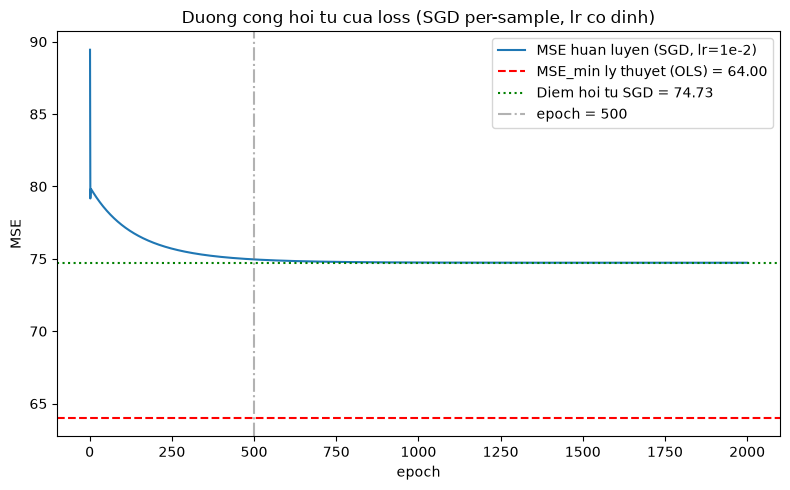

In [6]:
import matplotlib.pyplot as plt

w_long, b_long, hist_long = train(2000)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(hist_long) + 1), hist_long, label="MSE huan luyen (SGD, lr=1e-2)")
plt.axhline(mse_ols, color="red", ls="--", label=f"MSE_min ly thuyet (OLS) = {mse_ols:.2f}")
plt.axhline(hist_long[-1], color="green", ls=":", label=f"Diem hoi tu SGD = {hist_long[-1]:.2f}")
plt.axvline(500, color="gray", ls="-.", alpha=0.6, label="epoch = 500")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("Duong cong hoi tu cua loss (SGD per-sample, lr co dinh)")
plt.legend(); plt.tight_layout(); plt.show()

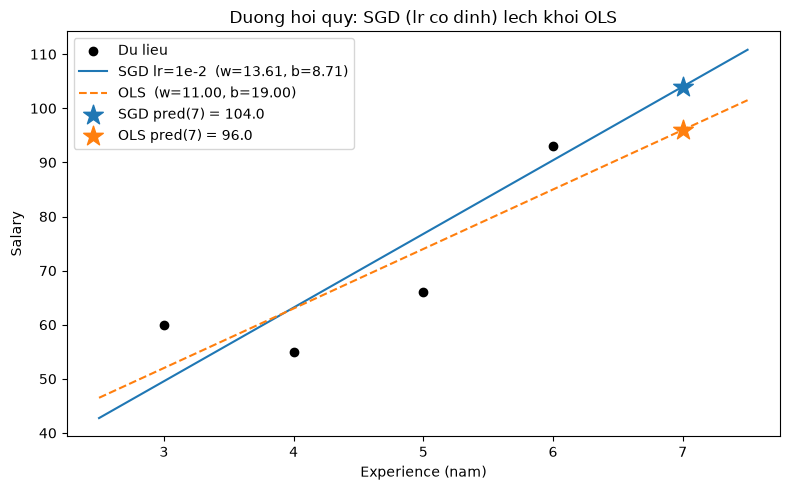

In [7]:
# Duong hoi quy: SGD (lr=1e-2) so voi OLS, kem du doan tai Experience = 7
xs = np.linspace(2.5, 7.5, 100)
p7_sgd = predict(w_long, b_long, 7)
p7_ols = w_ols * 7 + b_ols

plt.figure(figsize=(8, 5))
plt.scatter(x, y_train, color="black", zorder=5, label="Du lieu")
plt.plot(xs, w_long[0] * xs + b_long, color="C0",
         label=f"SGD lr=1e-2  (w={w_long[0]:.2f}, b={b_long:.2f})")
plt.plot(xs, w_ols * xs + b_ols, "--", color="C1",
         label=f"OLS  (w={w_ols:.2f}, b={b_ols:.2f})")
plt.scatter([7], [p7_sgd], marker="*", s=220, color="C0", zorder=6,
            label=f"SGD pred(7) = {p7_sgd:.1f}")
plt.scatter([7], [p7_ols], marker="*", s=220, color="C1", zorder=6,
            label=f"OLS pred(7) = {p7_ols:.1f}")
plt.xlabel("Experience (nam)"); plt.ylabel("Salary")
plt.title("Duong hoi quy: SGD (lr co dinh) lech khoi OLS")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Vì sao SGD chệch? Vai trò của tốc độ học cố định

Với tốc độ học **cố định**, SGD per-sample không dừng tại nghiệm tối ưu mà dao động quanh một **điểm cố định của phép cập nhật tuần hoàn** — điểm này phụ thuộc $\eta$ và lệch khỏi OLS một lượng tỉ lệ thuận với $\eta$. Có hai cách khử độ chệch, kiểm chứng bằng thực nghiệm:
1. **Giảm tốc độ học** $\eta \to 0$ (chạy đủ lâu): điểm hội tụ tiến dần về OLS.
2. **Dùng gradient toàn batch** (trung bình gradient trên cả $N$ mẫu trong mỗi bước): hội tụ đúng về OLS ngay cả khi $\eta$ không nhỏ, vì mỗi bước đi theo gradient *thật* của $\mathcal{L}$.

In [8]:
def batch_gd(lr, epoch_max):
    """Gradient descent toan batch: trung binh gradient tren ca N mau moi buoc."""
    w, b = initialize_params()
    for _ in range(epoch_max):
        e = (X_train.dot(w) + b) - y_train          # sai so tren ca tap
        w -= lr * 2 * np.mean(e[:, None] * X_train, axis=0)
        b -= lr * 2 * np.mean(e)
    return float(w[0]), float(b)

print("SGD per-sample, learning rate co dinh (chay den khi hoi tu):")
for lr, E in [(1e-2, 5000), (1e-3, 50000), (1e-4, 500000)]:
    w_c, b_c, hist_c = train(E, lr=lr)
    print(f"  lr={lr:.0e}  w={w_c[0]:7.4f}  b={b_c:7.4f}  "
          f"pred(7)={predict(w_c, b_c, 7):8.4f}  MSE={hist_c[-1]:7.4f}")

wb, bb = batch_gd(1e-2, 50000)
print()
print(f"Full-batch GD (lr=1e-2):  w={wb:7.4f}  b={bb:7.4f}  pred(7)={wb*7+bb:8.4f}")
print(f"OLS (chuan):              w={w_ols:7.4f}  b={b_ols:7.4f}  pred(7)={w_ols*7+b_ols:8.4f}")

SGD per-sample, learning rate co dinh (chay den khi hoi tu):


  lr=1e-02  w=13.6144  b= 8.7141  pred(7)=104.0146  MSE=74.7302


  lr=1e-03  w=11.2110  b=18.1692  pred(7)= 96.6461  MSE=64.0697


  lr=1e-04  w=11.0207  b=18.9185  pred(7)= 96.0633  MSE=64.0007



Full-batch GD (lr=1e-2):  w=11.0000  b=19.0000  pred(7)= 96.0000
OLS (chuan):              w=11.0000  b=19.0000  pred(7)= 96.0000


**Diễn giải kết quả.**
- **SGD per-sample, $\eta$ giảm dần:** $\eta=10^{-2}$ cho $w\approx 13.61,\ b\approx 8.71$ (chệch mạnh); $\eta=10^{-3}$ cho $w\approx 11.21,\ b\approx 18.17$ (gần OLS); $\eta=10^{-4}$ cho $w\approx 11.02,\ b\approx 18.92$ (gần như trùng OLS, MSE $\approx 64.0$). Độ chệch co về 0 khi $\eta \to 0$ — đúng như lý thuyết.
- **Full-batch GD** với chính $\eta=10^{-2}$ lại hội tụ **đúng** về $(w^\star=11,\ b^\star=19)$ và `pred(7)=96`, vì mỗi bước dùng gradient trung bình (gradient thật của $\mathcal{L}$), không bị nhiễu thứ tự mẫu.

Vậy độ chệch quan sát ở Phần 5 **không phải do thiếu epoch** mà do **tốc độ học cố định trong cập nhật per-sample**. Tăng epoch chỉ đưa ta tới điểm cố định nhanh hơn, không dời được điểm đó.

## 7. Kết luận

- **Hội tụ:** với $\eta=10^{-2}$, vòng lặp SGD per-sample hội tụ sau khoảng 500–2000 epoch; loss phẳng ở $\approx 74.73$, tham số $w\approx 13.61,\ b\approx 8.71$. Tăng epoch vượt 500 (1000/2000/5000) hầu như không đổi kết quả — đã chạm điểm cố định.
- **So sánh > 500 epoch:** sự khác biệt giữa 500 và 5000 epoch là rất nhỏ; lợi ích của việc tăng epoch bão hoà ngay sau ngưỡng hội tụ.
- **Chệch so với tối ưu:** điểm hội tụ của SGD lệch khỏi nghiệm OLS $(w^\star=11,\ b^\star=19,\ \text{MSE}=64)$ do tốc độ học cố định; khử chệch bằng cách giảm $\eta$ hoặc dùng full-batch GD.
- **Dự đoán lương khi `Experience = 7`:**
  - SGD per-sample ($\eta=10^{-2}$, đã hội tụ): $\approx 104.0$.
  - Nghiệm tối ưu OLS / full-batch GD: $96.0$ — đây là giá trị đáng tin cậy hơn về mặt thống kê.

> Bài học cô đọng: "vòng lặp hội tụ" và "hội tụ về nghiệm đúng" là hai chuyện khác nhau. Với SGD tốc độ học cố định, phải đối chiếu với nghiệm đóng (hoặc full-batch GD) để phát hiện độ chệch, và điều chỉnh $\eta$ (hoặc dùng lịch giảm $\eta$) thay vì chỉ tăng số epoch.